In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 86.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=902797b96507ace13b29d217cb2618fbbf3071bc0ef5021dc14d74b27a619f57
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# BB84 Quantum Key Distribution — No Attacker

This notebook simulates the BB84 protocol (Bennett & Brassard, 1984) between Alice and Bob with **no eavesdropper present**.

## Protocol overview
1. **Alice** generates random bits and random basis choices using quantum measurement.
2. **Alice** encodes each bit as a qubit using her chosen basis and sends it to Bob.
3. **Bob** independently chooses a random measurement basis for each qubit and measures it.
4. **Alice and Bob** publicly compare *bases only* (never the bits themselves).
5. They keep only the bits where their bases matched — this is the **shared secret key**.

All random choices are generated by measuring the quantum state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, which collapses to 0 or 1 with equal probability — true quantum randomness.

In [2]:
# Setup
simulator = BasicSimulator()

# Number of qubits Alice will send
N = 20

print(f"Simulating BB84 with N={N} qubits.")

Simulating BB84 with N=20 qubits.


## Choice of Number of Qubits

The value of `N` is not fixed by the BB84 protocol. In a real key-distribution system, Alice and Bob would use many more qubits to generate a long final key and to make statistical checks more reliable.

Here, `N = 20` is chosen as a small demonstration size so that the printed lists of bits and bases remain readable. Since Alice and Bob choose their bases randomly, only about half of the qubits are expected to survive basis comparison. Therefore, `N = 20` should produce roughly `10` sifted key bits on average.


## Quantum Random Number Generation

Below function is generated via preparing *n* qubits in the state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and measuring each one. This is used instead of `random.randint()` because BB84 is a quantum protocol. Measuring a qubit prepared in the superposition state $|+\rangle$ gives outcome `0` or `1` with equal probability, and the result is produced by quantum measurement rather than by a classical pseudo-random algorithm.


In [3]:
def quantum_random_bit():
  """
  Generate one truly random bit by preparing |+⟩ = (|0⟩+|1⟩)/√2
  and measuring it.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

# This calls quantum_random_bit() repeatedly for clarity.
def quantum_random_bits(n):
  """Generate n random bits by calling quantum_random_bit() n times."""
  return [quantum_random_bit() for _ in range(n)]

# Quick sanity check
sample = quantum_random_bits(10)
print("Sample quantum random bits:", sample)

Sample quantum random bits: [1, 1, 0, 0, 0, 0, 1, 1, 0, 1]


## Alice Part

Alice generates random data bits and random basis choices. She then encodes each bit as a qubit using the following encoding rule:

- Standard basis (basis=0):  $0 \rightarrow |0\rangle$,  $1 \rightarrow |1\rangle$
- Diagonal basis (basis=1):  $0 \rightarrow |+\rangle$,  $1 \rightarrow |-\rangle$

In this no-attacker version, Alice sends the prepared qubits directly to Bob through the quantum channel.

In [4]:
alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def encoding_circuit(bit, basis):
  """Return Alice's 1-qubit encoding circuit without measurement."""
  qc = QuantumCircuit(1)
  if bit == 1:
      qc.x(0)
  if basis == 1:
      qc.h(0)
  return qc

def alice_prepare_qubit(bit, basis):
  """
  Alice prepares a 1-qubit circuit encoding `bit` in `basis`.

  Standard (basis=0):  bit 0 → |0⟩ (no gates)
                        bit 1 → |1⟩ (X gate)
  Diagonal (basis=1):  bit 0 → |+⟩ (H gate)
                        bit 1 → |−⟩ (X then H)
  """
  qc = QuantumCircuit(1, 1)
  qc.compose(encoding_circuit(bit, basis), inplace=True)
  return qc

# Alice prepares all qubits and places them on the quantum channel
quantum_channel = [alice_prepare_qubit(alice_bits[i], alice_bases[i]) for i in range(N)]

print("=== ALICE ===")
print(f"Bits:   {alice_bits}")
print(f"Bases:  {['S' if b==0 else 'D' for b in alice_bases]}")
print(f"\nAlice has prepared {N} qubits and sent them to Bob.")

=== ALICE ===
Bits:   [0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1]
Bases:  ['D', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'S', 'D', 'S', 'D', 'S', 'S', 'D', 'D', 'D', 'D', 'S', 'D']

Alice has prepared 20 qubits and sent them to Bob.


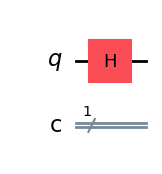

In [5]:
# Show Alice's first prepared qubit as a circuit diagram.
inspection_index = 0
alice_example = quantum_channel[inspection_index]
alice_example.draw("mpl")

In [6]:
# Calculate the state from |0> and display it symbolically.
# Uses the measurement-free version of Alice's same bit and basis.
alice_unitary_example = encoding_circuit(alice_bits[inspection_index], alice_bases[inspection_index])
state = Statevector.from_int(0, 2)
state = state.evolve(alice_unitary_example)
state.draw("latex")

<IPython.core.display.Latex object>

In [7]:
U = Operator(alice_unitary_example)
array_to_latex(U)

<IPython.core.display.Latex object>

## Bob Part

From lecture, Bob receives qubits from the channel and for each qubit he independently picks a random measurement basis.

For Measurement rule:
- Standard basis  (basis=0): measure directly.
- Diagonal basis  (basis=1): apply H first, then measure.

H maps $|+\rangle \rightarrow |0\rangle$, so the standard measurement now reveals which diagonal state we had.

### Outcomes
If Bob picks the **SAME** basis as Alice: he always recovers Alice's bit.

If he picks the **WRONG** basis: he gets a uniformly random result.

In [8]:
bob_bases = quantum_random_bits(N)

def bob_measure_qubit(qubit_circuit, basis):
  """
  Bob measures `qubit_circuit` in `basis`.

  Standard (basis=0): measure in the {|0⟩, |1⟩} basis.
  Diagonal (basis=1): apply H then measure (equivalent to
                      measuring in the {|+⟩, |−⟩} basis).
  Returns the measured bit (0 or 1).
  """
  qc = qubit_circuit.copy()
  if basis == 1:
      qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

bob_bits = [bob_measure_qubit(quantum_channel[i], bob_bases[i]) for i in range(N)]

print("=== BOB ===")
print(f"Bases:  {['S' if b==0 else 'D' for b in bob_bases]}")
print(f"Bits:   {bob_bits}")

=== BOB ===
Bases:  ['D', 'D', 'D', 'S', 'S', 'S', 'S', 'S', 'D', 'S', 'S', 'D', 'D', 'S', 'S', 'D', 'D', 'D', 'D', 'S']
Bits:   [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0]


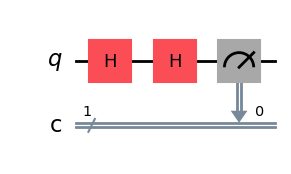

In [9]:
bob_measurement_example = quantum_channel[inspection_index].copy()
if bob_bases[inspection_index] == 1:
    bob_measurement_example.h(0)
bob_measurement_example.measure(0, 0)
bob_measurement_example.draw("mpl")

## Public Channel: Basic Reconciliation

Alice and Bob will annouce only their basis choices, not their bit values, over a public channel. Revealing the bases is safe because the secret key information is stored in the measured bit values, which remain private.

They keep only the positions where they used the same basis. When Alice and Bob use matching bases, Bob should recover Alice's bit exactly in the no-attacker case. When their bases differ, Bob's measurement result is effectively random, so those positions are discarded.

Because each person chooses between two bases randomly, about half of the positions are expected to match. This means the BB84 protocol typically produces a sifted key of length around $\frac{N}{2}$.


In [10]:
matching_indices = [i for i in range(N) if alice_bases[i] == bob_bases[i]]

print("=== PUBLIC CHANNEL: BASIS COMPARISON ===")
print(f"Total qubits sent : {N}")
print(f"Matching positions: {len(matching_indices)}  (expected ~{N//2})")
print(f"Discarded positions: {N - len(matching_indices)}")

=== PUBLIC CHANNEL: BASIS COMPARISON ===
Total qubits sent : 20
Matching positions: 12  (expected ~10)
Discarded positions: 8


The histogram below shows Bob's aggregated observed classical outcomes across all `N` received qubits. It is a measurement-count summary, not the final secret key and not the basis-sifting result.

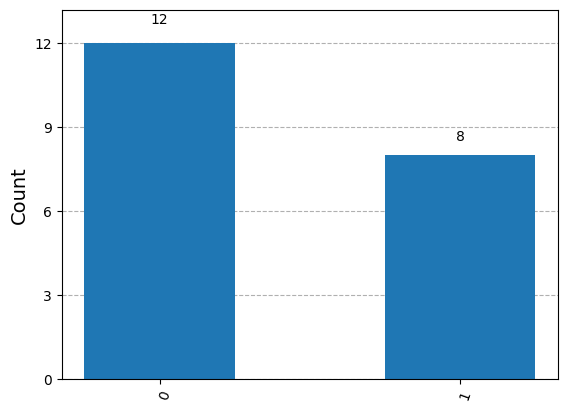

In [11]:
bob_measurement_counts = {
    "0": bob_bits.count(0),
    "1": bob_bits.count(1),
}
plot_histogram(bob_measurement_counts)

## Key Extraction

The shared key is formed by taking Alice's and Bob's bits only at the matching-basis positions. In the no-attacker case, these bits should be identical because Bob measured in the same basis that Alice used to prepare each qubit.

The output below compares Alice's extracted key with Bob's extracted key. A match confirms that the protocol produced a shared secret key from the transmitted qubits.

*If the key bits are uniformly random, private, and used only once, they can be used as a one-time pad, which provides information-theoretic security.*


In [12]:
alice_key = [alice_bits[i] for i in matching_indices]
bob_key   = [bob_bits[i]   for i in matching_indices]

print("=== SHARED SECRET KEY ===")
print(f"Alice's key : {alice_key}")
print(f"Bob's key   : {bob_key}")
print()

if alice_key == bob_key:
  print(f"Keys MATCH! Shared key length: {len(alice_key)} bits.")
  print("Alice and Bob now share a secret key they can use as a one-time pad.")
else:
  # Count positions where Alice and Bob's bits differ (True=1, False=0).
  mismatches = sum(a != b for a, b in zip(alice_key, bob_key))
  print(f"Keys do NOT match ({mismatches} mismatches) — this should not happen without an attacker.")

=== SHARED SECRET KEY ===
Alice's key : [0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]
Bob's key   : [0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]

Keys MATCH! Shared key length: 12 bits.
Alice and Bob now share a secret key they can use as a one-time pad.


## Summary

The summary checks the main outcome of the no-attacker BB84 run: Alice and Bob should obtain identical keys at all matching-basis positions. A zero mismatch result is expected here because no eavesdropper disturbed the qubits. The basis-match percentage also shows the efficiency of the protocol, which is expected to be close to 50%.

In [13]:
print("===== BB84 PROTOCOL SUMMARY (No Attacker) =====")
print(f"  Qubits sent by Alice    : {N}")
print(f"  Basis matches           : {len(matching_indices)} (~{100*len(matching_indices)/N:.0f}%)")
print(f"  Final key length        : {len(alice_key)} bits")
print(f"  Keys agree              : {alice_key == bob_key}")
print()
print("Protocol complete. The shared key can be used as a one-time pad.")

===== BB84 PROTOCOL SUMMARY (No Attacker) =====
  Qubits sent by Alice    : 20
  Basis matches           : 12 (~60%)
  Final key length        : 12 bits
  Keys agree              : True

Protocol complete. The shared key can be used as a one-time pad.
